In [1]:
pip install pandas scikit-learn openpyxl

Note: you may need to restart the kernel to use updated packages.


In [99]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [101]:
import pandas as pd

df = pd.read_csv("House_Rent_Dataset.csv")

df.head()

,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,2022-05-18,2,10000,1100,Ground out of 2,Super Area,Bandel,Kolkata,Unfurnished,Bachelors/Family,2,Contact Owner
1,2022-05-13,2,20000,800,1 out of 3,Super Area,"Phool Bagan, Kankurgachi",Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
2,2022-05-16,2,17000,1000,1 out of 3,Super Area,Salt Lake City Sector 2,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
3,2022-07-04,2,10000,800,1 out of 2,Super Area,Dumdum Park,Kolkata,Unfurnished,Bachelors/Family,1,Contact Owner
4,2022-05-09,2,7500,850,1 out of 2,Carpet Area,South Dum Dum,Kolkata,Unfurnished,Bachelors,1,Contact Owner


In [103]:
df = df[['City','BHK','Rent','Area Locality','Furnishing Status','Tenant Preferred','Bathroom']]

df.head()

,City,BHK,Rent,Area Locality,Furnishing Status,Tenant Preferred,Bathroom
0,Kolkata,2,10000,Bandel,Unfurnished,Bachelors/Family,2
1,Kolkata,2,20000,"Phool Bagan, Kankurgachi",Semi-Furnished,Bachelors/Family,1
2,Kolkata,2,17000,Salt Lake City Sector 2,Semi-Furnished,Bachelors/Family,1
3,Kolkata,2,10000,Dumdum Park,Unfurnished,Bachelors/Family,1
4,Kolkata,2,7500,South Dum Dum,Unfurnished,Bachelors,1


In [105]:
df = df.dropna().reset_index(drop=True)

In [107]:
def rent_category(price):

    if price < 10000:
        return "low_rent"
    
    elif price < 20000:
        return "medium_rent"
    
    else:
        return "high_rent"

df["rent_category"] = df["Rent"].apply(rent_category)

In [109]:
df["tags"] = (
    df["City"].astype(str) + " " +
    df["Area Locality"].astype(str) + " " +
    df["Furnishing Status"].astype(str) + " " +
    df["Tenant Preferred"].astype(str)
)

In [111]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer()

feature_matrix = vectorizer.fit_transform(df["tags"])

In [113]:
from sklearn.metrics.pairwise import cosine_similarity

similarity = cosine_similarity(feature_matrix)

In [114]:
indices = pd.Series(df.index, index=df["Area Locality"]).drop_duplicates()

In [117]:
import pandas as pd

indices = pd.Series(df.index, index=df["Area Locality"]).drop_duplicates()

In [153]:
df["City"].unique()[:20]

array(['Kolkata', 'Mumbai', 'Bangalore', 'Delhi', 'Chennai', 'Hyderabad'],
      dtype=object)

In [83]:
df["Area Locality"].unique()[:20]

array(['Bandel', 'Phool Bagan, Kankurgachi', 'Salt Lake City Sector 2',
       'Dumdum Park', 'South Dum Dum', 'Thakurpukur', 'Malancha',
       'Palm Avenue Kolkata, Ballygunge', 'Natunhat',
       'Action Area 1, Rajarhat Newtown', 'Keshtopur',
       'Tarulia, Keshtopur', 'Dum Dum Metro', 'Paschim Barisha',
       'New Town Action Area 1', 'Barasat', 'Behala', 'Behala Chowrasta',
       'Santoshpur', 'Garia Station, Garia'], dtype=object)

In [119]:
def recommend_pg(locality, top_n=5):

    if locality not in indices:
        return "Locality not found in dataset"

    idx = indices[locality]

    # Convert similarity row to a flat list of numbers
    sim_scores = list(enumerate(similarity[idx].ravel()))

    # Sort by similarity score
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

    # Remove the first item (it's the same house)
    sim_scores = sim_scores[1:top_n+1]

    house_indices = [i[0] for i in sim_scores]

    return df.iloc[house_indices][
        ['City','Area Locality','BHK','Rent','Furnishing Status','Tenant Preferred']
    ]

In [149]:
def pg_agent():

    print("Smart PG Recommendation Agent")
    print("--------------------------------")

    city = input("Enter city: ")
    budget = int(input("Enter maximum rent: "))
    tenant = input("Tenant type (Bachelors/Family): ")

    # Filter dataset based on user input
    filtered = df[
        (df["City"].str.contains(city, case=False)) &
        (df["Rent"] <= budget) &
        (df["Tenant Preferred"].str.contains(tenant, case=False))
    ]

    if len(filtered) == 0:
        print("\n❌ No PGs found matching your criteria.")
        return

    print("\nRecommended PG Accommodations:\n")

    results = filtered.head(5)

    for index, row in results.iterrows():

        print(
            f"{row['Area Locality']} | {row['City']} | "
            f"BHK: {row['BHK']} | Rent: ₹{row['Rent']} | "
            f"Furnishing: {row['Furnishing Status']} | "
            f"Tenant: {row['Tenant Preferred']}"
        )

In [151]:
pg_agent()


Smart PG Recommendation Agent
--------------------------------


Enter city:  Bangalore
Enter maximum rent:  11000
Tenant type (Bachelors/Family):  Bachelors



Recommended PG Accommodations:

Nagappa Reddy layout-Dooravani Nagar | Bangalore | BHK: 2 | Rent: ₹10500 | Furnishing: Semi-Furnished | Tenant: Bachelors/Family
Talaghattapura | Bangalore | BHK: 2 | Rent: ₹10000 | Furnishing: Furnished | Tenant: Bachelors/Family
Rajajinagar | Bangalore | BHK: 1 | Rent: ₹7500 | Furnishing: Unfurnished | Tenant: Bachelors/Family
Ramamurthy Nagar | Bangalore | BHK: 2 | Rent: ₹10500 | Furnishing: Semi-Furnished | Tenant: Bachelors/Family
Thanisandra | Bangalore | BHK: 1 | Rent: ₹8000 | Furnishing: Semi-Furnished | Tenant: Bachelors/Family


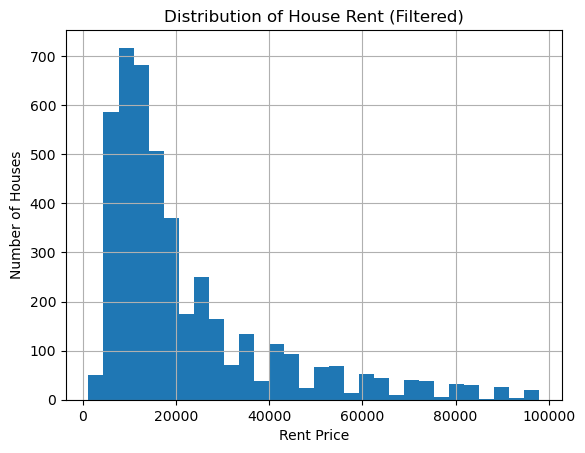

In [137]:
plt.figure()

df[df["Rent"] < 100000]["Rent"].hist(bins=30)

plt.title("Distribution of House Rent (Filtered)")
plt.xlabel("Rent Price")
plt.ylabel("Number of Houses")

plt.show()

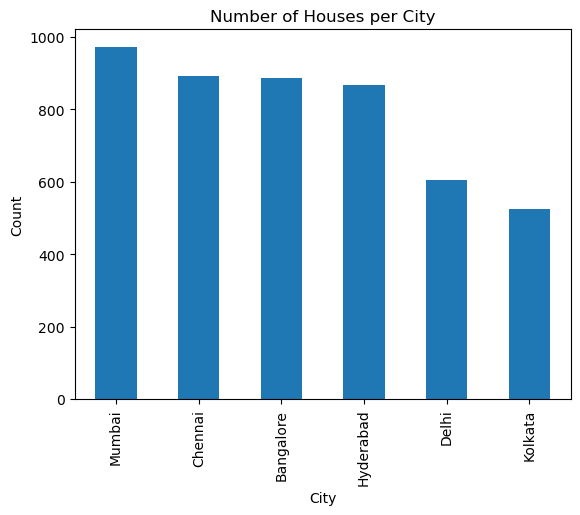

In [129]:
df["City"].value_counts().plot(kind="bar")

plt.title("Number of Houses per City")
plt.xlabel("City")
plt.ylabel("Count")

plt.show()

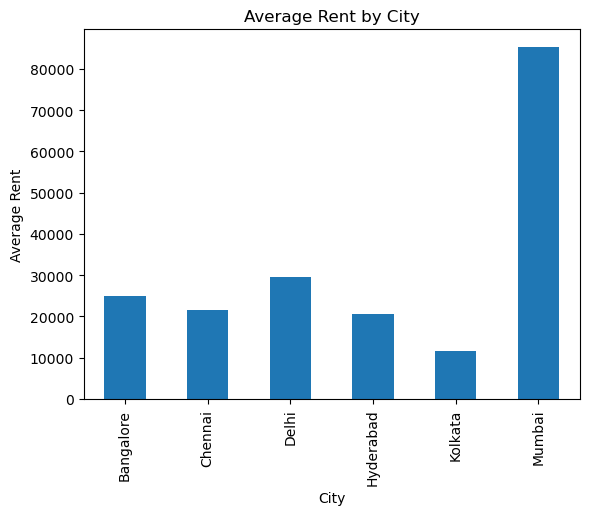

In [131]:
avg_rent = df.groupby("City")["Rent"].mean()

avg_rent.plot(kind="bar")

plt.title("Average Rent by City")
plt.xlabel("City")
plt.ylabel("Average Rent")

plt.show()

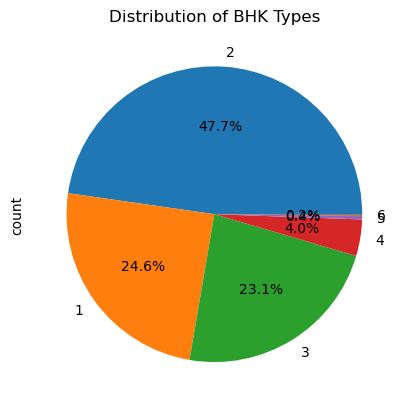

In [133]:
df["BHK"].value_counts().plot(kind="pie", autopct='%1.1f%%')

plt.title("Distribution of BHK Types")

plt.show()

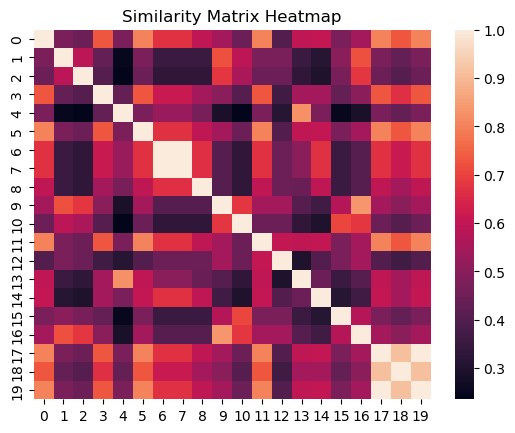

In [135]:
import seaborn as sns

plt.figure()

sns.heatmap(similarity[:20,:20])

plt.title("Similarity Matrix Heatmap")

plt.show()